# 01. News Dataset EDA (Exploratory Data Analysis)

In [1]:
from datasets import load_dataset

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading and Saving

In [2]:
dataset = load_dataset(
    "fahadh4ilyas/indonesian_news_datasets"
)

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['id', 'source', 'title', 'image', 'url', 'content', 'date', 'embedding', 'created_at', 'updated_at', 'summary', 'nomic_embedding', 'label'],
        num_rows: 25835
    })
    test: Dataset({
        features: ['id', 'source', 'title', 'image', 'url', 'content', 'date', 'embedding', 'created_at', 'updated_at', 'summary', 'nomic_embedding', 'label'],
        num_rows: 6459
    })
})

In [4]:
train_df = dataset["train"].to_pandas()

train_df.shape

(25835, 13)

In [5]:
economy_df = train_df[
    train_df["label"] == "EKONOMI_BISNIS"
].copy()

In [6]:
economy_df.shape

(6867, 13)

In [7]:
## Save data
economy_df.to_parquet(
    "../data/raw/economy_news.parquet",
    index=False
)

In [8]:
## Validation saved data

import os

os.path.exists(
    "../data/raw/economy_news.parquet"
)

True

## 2. Dataset Overview

In [9]:
train_df.head()

,id,source,title,image,url,content,date,embedding,created_at,updated_at,summary,nomic_embedding,label
0,19718,kumparan,Identitas Mayat di Pekarangan Rumah Warga Bany...,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/jatim-now/identitas-mayat...,- Masih ingat kasus penemuan mayat wanita di p...,2023-03-19 08:50:05,"[0.009389602,-0.010916472,0.0025594658,-0.0173...",2023-03-19 09:20:14.660574,2023-03-19 09:20:14.660574,Identitas mayat wanita yang ditemukan di pekar...,"[-0.6505534648895264, 0.37138256430625916, -1....",HUKUM_KRIMINAL
1,55006,suara,Camat Cengkareng Pastikan Pengurus RT di Kapuk...,https://media.suara.com/pictures/970x544/2023/...,https://www.suara.com/news/2023/04/06/192021/c...,Suara.com - Camat Cengkareng Ahmad Farih angka...,2023-04-06 12:20:21,"[0.004432778,-0.008700278,0.002332084,-0.01802...",2023-04-07 01:25:12.754979,2023-04-07 01:25:12.754979,"Camat Cengkareng, Ahmad Farih, mencabut surat ...","[-0.10704676061868668, 1.0061707496643066, -1....",HUKUM_KRIMINAL
2,17211,okezone,AS Akhirnya Tunjuk Dubes untuk India Usai Perg...,https://img.okezone.com/dynamic/content/2023/0...,https://news.okezone.com/read/2023/03/17/18/27...,NEW YORK - Pemerintah Amerika Serikat (AS) tel...,2023-03-17 02:11:44,"[0.0065433956,-0.027488708,0.011984407,-0.0054...",2023-03-18 00:45:11.852474,2023-03-18 00:45:11.852474,"Mantan Wali Kota Los Angeles, Eric Garcetti, t...","[-0.13377293944358826, 0.6232709288597107, -2....",POLITIK_PEMERINTAHAN
3,34715,jawapos,"Indonesia Graveyard, Jelajahi Makam-Makam Kuno",https://cdn-asset.jawapos.com/wp-content/uploa...,https://www.jawapos.com/nasional/25/03/2023/in...,lebih dari enam tahun Ruri bersama teman-tema...,2023-03-25 13:48:15,"[0.009994787,-0.017737046,0.026592698,-0.02682...",2023-03-27 00:03:12.746411,2023-03-27 00:03:12.746411,Komunitas Indonesia Graveyard telah menjelajah...,"[0.525788426399231, 0.05549769848585129, -1.65...",BENCANA_LINGKUNGAN
4,26994,kumparan,Melihat Khusyuknya Salat Tarawih Pertama di Ma...,https://blue.kumparan.com/image/upload/fl_prog...,https://kumparan.com/kumparannews/melihat-khus...,Masyarakat mulai melaksanakan ibadah salat ber...,2023-03-22 14:36:33,"[-0.0042723035,-0.02660871,-0.016681418,-0.011...",2023-03-22 14:50:14.057845,2023-03-22 14:50:14.057845,Masyarakat telah melaksanakan ibadah salat ber...,"[0.15611819922924042, 0.2497233748435974, -2.2...",POLITIK_PEMERINTAHAN


In [10]:
train_df.columns.tolist()

['id',
 'source',
 'title',
 'image',
 'url',
 'content',
 'date',
 'embedding',
 'created_at',
 'updated_at',
 'summary',
 'nomic_embedding',
 'label']

In [11]:
train_df["label"].value_counts().to_frame()

,count
label,
POLITIK_PEMERINTAHAN,7954
HUKUM_KRIMINAL,7061
EKONOMI_BISNIS,6867
BENCANA_LINGKUNGAN,2138
OLAHRAGA,1232
TEKNOLOGI_DIGITAL,583


In [12]:
train_df["created_at"] = pd.to_datetime(
    train_df["created_at"]
)

train_df["created_at"].min()

Timestamp('2023-03-03 16:08:03.144472')

In [13]:
train_df["created_at"].max()

Timestamp('2023-04-11 20:20:10.989219')

In [14]:
train_df["date"] = pd.to_datetime(
    train_df["date"]
)

train_df["date"].min()

Timestamp('2018-08-10 05:11:58')

In [15]:
train_df["date"].max()

Timestamp('2023-04-11 20:13:25')

In [16]:
economy_df.shape

(6867, 13)

In [17]:
economy_df["date"] = pd.to_datetime(
    economy_df["date"]
)

economy_df["date"].min()

Timestamp('2023-03-03 13:00:00')

In [18]:
economy_df["date"].max()

Timestamp('2023-04-11 15:46:34')

In [19]:
economy_df["created_at"] = pd.to_datetime(
    economy_df["created_at"]
)

economy_df["created_at"].min()

Timestamp('2023-03-03 16:08:03.144472')

In [20]:
economy_df["date"].max()

Timestamp('2023-04-11 15:46:34')

In [21]:
economy_df[[
    "date",
    "title",
    "summary"
]].head()

,date,title,summary
9,2023-03-16 07:16:28,"Tok! BI Tahan Suku Bunga Acuan di Level 5,75%",Bank Indonesia memutuskan untuk mempertahankan...
12,2023-03-19 02:11:48,'Tidak Foya-foya' Tips Walkot Depok ke Warga B...,"Wali Kota Depok, Mohammad Idris, memberikan ti..."
13,2023-03-22 05:45:35,"Besok Puasa, Daging Sapi Lokal Tembus Rp140 Ri...","Harga daging sapi lokal di Pasar Timbul, Cigan..."
25,2023-03-14 09:18:39,Cara dan Syarat Pengajuan KUR BCA Online Terbaru,Bank BCA menyediakan bantuan modal berupa kred...
27,2023-03-14 11:13:41,"Depo Plumpang Belum Akan Ditutup, Ini Alasan B...",Pertamina akan melakukan perluasan buffer zone...


In [22]:
economy_df.sample(
    20,
    random_state=42,
)[["date", "title"]]

,date,title
5857,2023-03-21 06:57:40,"BCA Syariah Cetak Laba Bersih Rp 117,6 Miliar ..."
4637,2023-03-11 17:10:07,"SVB Kebangkrutan Bank Terbesar Sejak 2008, Mil..."
7376,2023-03-27 11:14:00,"AS Pening, 'Badai' Baru Bikin Penampakan Reses..."
11064,2023-03-21 02:36:29,"Pertumbuhan Ekonomi Indonesia Ditaksir 4,9 sam..."
18604,2023-03-16 02:46:57,Jokowi Buka Opsi Impor Beras 500 Ribu Ton Lagi
5699,2023-04-03 03:26:29,Daftar Harga Emas Antam Hari Ini Usai Turun Rp...
24499,2023-03-28 02:02:18,"Turun Ceban, Harga Emas Antam Hari Ini Dijual ..."
10960,2023-03-17 13:00:57,Entitas Nikel Harita Group Targetkan Pendapata...
19201,2023-03-16 11:10:22,"Ramai Panik Silicon Valley Bank Bangkrut, Bos ..."
6352,2023-03-19 07:57:57,"Lakukan Transisi Energi, PGE Bukukan Pendapata..."


In [23]:
economy_df["title"].sample(
    20,
    random_state=42,
).tolist()

['BCA Syariah Cetak Laba Bersih Rp 117,6 Miliar di 2022',
 'SVB Kebangkrutan Bank Terbesar Sejak 2008, Miliaran Dolar Tersandera',
 "AS Pening, 'Badai' Baru Bikin Penampakan Resesi Kian Nyata",
 'Pertumbuhan Ekonomi Indonesia Ditaksir 4,9 sampai 5,7 Persen pada 2025',
 'Jokowi Buka Opsi Impor Beras 500 Ribu Ton Lagi',
 'Daftar Harga Emas Antam Hari Ini Usai Turun Rp4.000/Gram',
 'Turun Ceban, Harga Emas Antam Hari Ini Dijual Rp1.077.000/Gram',
 'Entitas Nikel Harita Group Targetkan Pendapatan Naik 100% Usai IPO',
 'Ramai Panik Silicon Valley Bank Bangkrut, Bos OJK Bilang Gini',
 'Lakukan Transisi Energi, PGE Bukukan Pendapatan dari Carbon Credit',
 'Pernah Terseret Kasus Pajak, Saham Bank Panin Masih Menarik?',
 'Naik Rp 10 Ribu, Harga Emas Antam Hari Ini Rp 1.083.000 per Gram',
 'Duduk Perkara Silicon Valley Bank Bangkrut dalam 48 Hari, Kini Dibeli Rp 18 Ribu',
 'Deretan Orang Terkaya Indonesia yang Masuk Daftar Miliarder Dunia',
 'Siapkan Rp500 Juta, OCBC NISP Bakal Buyback 402 Ribu 

In [24]:
def get_dataset_overview(df):
    """
    Generate a high-level overview of a dataset.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    dict
        Dataset overview containing shape,
        column names, and data types.
    """

    overview = {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict()
    }

    return overview

In [25]:
data_overview = get_dataset_overview(
    economy_df
)

data_overview

{'rows': 6867,
 'columns': 13,
 'column_names': ['id',
  'source',
  'title',
  'image',
  'url',
  'content',
  'date',
  'embedding',
  'created_at',
  'updated_at',
  'summary',
  'nomic_embedding',
  'label'],
 'dtypes': {'id': 'int64',
  'source': 'str',
  'title': 'str',
  'image': 'str',
  'url': 'str',
  'content': 'str',
  'date': 'datetime64[s]',
  'embedding': 'str',
  'created_at': 'datetime64[us]',
  'updated_at': 'str',
  'summary': 'str',
  'nomic_embedding': 'str',
  'label': 'str'}}

## 3. Data Quality Checks

In [26]:
def check_missing_values(df):
    """
    Calculate missing value for each column

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    pandas.Series
        Missing value count per column.
    """

    return df.isnull().sum()

In [27]:
missing_values = check_missing_values(
    economy_df
)

missing_values

id                 0
source             0
title              0
image              9
url                0
content            0
date               0
embedding          0
created_at         0
updated_at         0
summary            1
nomic_embedding    0
label              0
dtype: int64

In [28]:
def check_duplicate_titles(df):
    """
    Count duplicated news title.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    int
        Number of duplicated news titles.
    """

    return df["title"].duplicated().sum()

In [29]:
duplicate_titles = check_duplicate_titles(
    economy_df
)

print(f"Duplicate titles: {duplicate_titles}")

Duplicate titles: 22


In [30]:
## See the detail of duplicate titles
duplicate_rows = economy_df[
    economy_df["title"].duplicated(
        keep=False
    )
]

duplicate_rows[
    ["date", "source", "title"]
].sort_values("title")

,date,source,title
10710,2023-03-18 02:00:00,suara,Akademisi Nilai Program Food Estate di Kalteng...
10897,2023-03-18 00:20:51,okezone,Akademisi Nilai Program Food Estate di Kalteng...
13824,2023-03-18 09:10:03,tempo,Akademisi Nilai Program Food Estate di Kalteng...
19963,2023-03-19 01:13:13,jawapos,BI: Kenaikan Bunga Bukan Satu-Satunya Instrume...
25309,2023-03-19 01:13:13,jawapos,BI: Kenaikan Bunga Bukan Satu-Satunya Instrume...
11786,2023-04-04 10:28:54,suara,"Dukung Satgas RAFI, Wakil Komut Pertamina Past..."
12976,2023-04-04 10:33:46,okezone,"Dukung Satgas RAFI, Wakil Komut Pertamina Past..."
6939,2023-04-06 09:59:55,okezone,"Dukung UMKM Naik Kelas, Pegadaian dan PNM Gela..."
9781,2023-04-06 16:15:43,tempo,"Dukung UMKM Naik Kelas, Pegadaian dan PNM Gela..."
6946,2023-04-05 02:51:35,okezone,"HUT ke-122, Begini Sejarah Pegadaian Era Pra K..."


A small number of duplicated titles were identified.
Most duplicates originated from different news sources
reporting the same event and were therefore retained.

## 4. Temporal Analysis

In [31]:
def get_news_by_year(df):
    """
    Calculate the number of news articles published per year.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    pandas.Series
        News count per year.
    """

    return (
        df["date"]
        .dt.year
        .value_counts()
        .sort_index()
    )

In [32]:
news_by_year = get_news_by_year(
    economy_df
)

news_by_year

date
2023    6867
Name: count, dtype: int64

In [33]:
def get_news_by_month(df):
    """
    Calculate the number of news articles published per month.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    pandas.Series
        News count per month.
    """

    return (
        df["date"]
        .dt.to_period("M")
        .value_counts()
        .sort_index()
    )

In [34]:
news_by_month = get_news_by_month(
    economy_df
)

news_by_month

date
2023-03    4495
2023-04    2372
Freq: M, Name: count, dtype: int64

In [35]:
train_df["date"].dt.year.value_counts().sort_index()

date
2018        1
2023    25834
Name: count, dtype: int64

In [36]:
train_df[
    [
        "date",
        "created_at",
        "updated_at"
    ]
].sample(
    10,
    random_state=42
)

,date,created_at,updated_at
10906,2023-04-04 12:10:59,2023-04-05 00:25:12.291000,2023-04-05 00:25:12.291
10658,2023-04-10 03:41:31,2023-04-10 04:15:13.795657,2023-04-10 04:15:13.795657
9500,2023-04-10 03:36:08,2023-04-10 04:00:13.182493,2023-04-10 04:00:13.182493
16797,2023-04-01 09:27:34,2023-04-02 00:15:14.761744,2023-04-02 00:15:14.761744
10324,2023-04-08 14:15:20,2023-04-10 00:15:12.714745,2023-04-10 00:15:12.714745
9754,2023-03-18 09:10:03,2023-03-18 15:00:17.575163,2023-03-18 15:00:17.575163
6951,2023-03-23 15:01:48,2023-03-26 00:15:13.173668,2023-03-26 00:15:13.173668
15902,2023-03-28 03:56:14,2023-03-29 00:03:15.911910,2023-03-29 00:03:15.91191
5505,2023-04-10 23:58:24,2023-04-11 00:05:11.598419,2023-04-11 00:05:11.598419
11614,2023-04-09 20:35:09,2023-04-10 00:20:11.322400,2023-04-10 00:20:11.3224


In [37]:
def get_news_by_day(df):
    """
    Calculate daily news volume.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    pandas.Series
        Daily news counts.
    """

    return (
        df["date"]
        .dt.date
        .value_counts()
        .sort_index()
    )

In [38]:
daily_news = get_news_by_day(
    economy_df
)

daily_news.head()

date
2023-03-03     1
2023-03-04     2
2023-03-05     4
2023-03-06    10
2023-03-08     5
Name: count, dtype: int64

In [39]:
def plot_daily_news_volume(daily_news):
    """
    Visualize daily news volume.

    Parameters
    ----------
    daily_news : pandas.Series
        Daily news counts.
    """

    plt.figure(figsize=(14, 5))
    
    daily_news.plot()

    plt.title(
        "Daily Economic News Volume"
    )

    plt.xlabel(
        "Date"
    )

    plt.ylabel(
        "Number of Articles"
    )

    plt.tight_layout()

    plt.show()

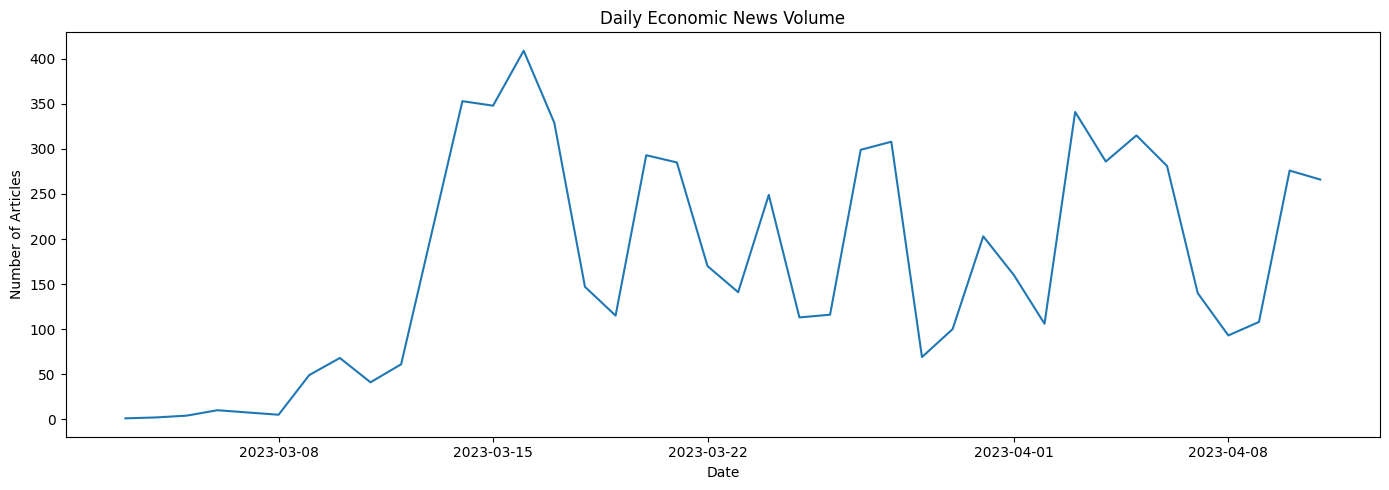

In [40]:
plot_daily_news_volume(
    daily_news
)

Daily news volume increased substantially in mid-March 2023, suggesting heightened media attention to economic and financial events. Several major global banking developments occurred during this period, including the Silicon Valley Bank collapse and concerns surrounding Credit Suisse.

## 5. Source Analysis

In [41]:
def get_top_news_sources(df):
    """
    Calculate news article counts by source.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    pandas.Series
        News count per source.
    """

    return df["source"].value_counts()

In [42]:
news_by_source = get_top_news_sources(
    economy_df
)

news_by_source

source
cnbcindonesia    2236
okezone          1474
kumparan         1110
tempo             792
suara             575
cnnindonesia      459
jawapos           221
Name: count, dtype: int64

In [43]:
def plot_news_source_distribution(news_by_source):
    """
    Visualize news article distribution by source.

    Parameters
    ----------
    news_by_source : pandas.Series
        News count per source.
    """
    plt.figure(figsize=(10, 5))

    news_by_source.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "Economic News Distribution by Source"
    )

    plt.xlabel(
        "Number of Articles"
    )

    plt.ylabel(
        "News Source"
    )

    plt.tight_layout()

    plt.show()

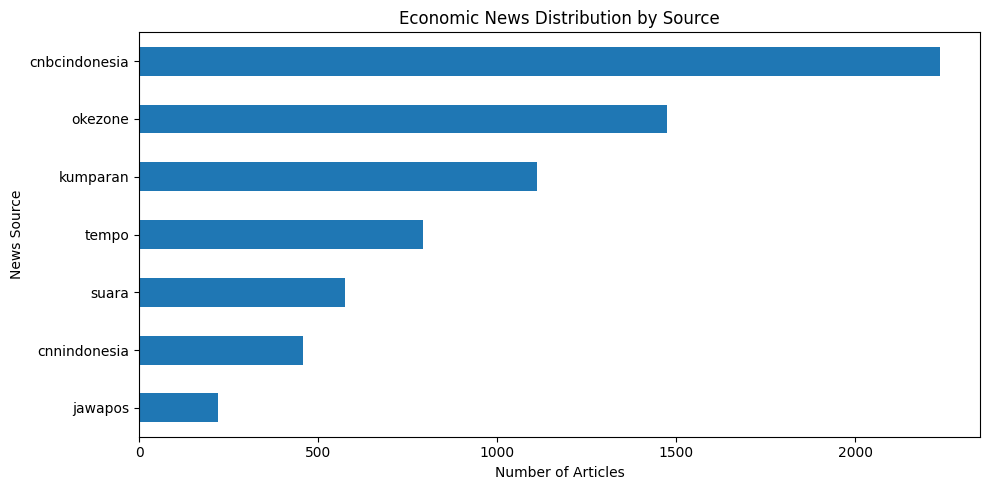

In [44]:
plot_news_source_distribution(
    news_by_source
)

## 6. Summary Length Analysis

In [45]:
def calculate_summary_length(df):
    """
    Calculate summary length in words.

    Paremeters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    Returns
    -------
    pandas.Series
        Summary length in words.
    """

    return (
        df["summary"]
        .fillna("")
        .apply(lambda x: len(str(x).split()))
    )

In [46]:
summary_length = calculate_summary_length(
    economy_df
)

summary_length.describe()

count    6867.000000
mean       65.488860
std        15.032065
min         0.000000
25%        56.000000
50%        67.000000
75%        76.000000
max       119.000000
Name: summary, dtype: float64

The summary field contains a relatively rich amount of information, with an average length of approximately 65 words. This suggests that article summaries provide sufficient textual context for sentiment analysis without requiring the full article content. Using summaries instead of articles can significantly reduce computational cost while preserving most of the important information.

In [47]:
def plot_summary_length_distribution(
    summary_length
):
    """
    Visualize summary length distribution,

    Parameters
    ----------
    summary_length : pandas.Series
        Summary length in words.
    """

    plt.figure(figsize=(10, 5))

    sns.histplot(
        summary_length,
        bins=30
    )

    plt.title(
        "Summary Length Distribution"
    )

    plt.xlabel(
        "Number of Words"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.axvline(
        summary_length.mean(),
        linestyle="--",
        label="Mean"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()
    

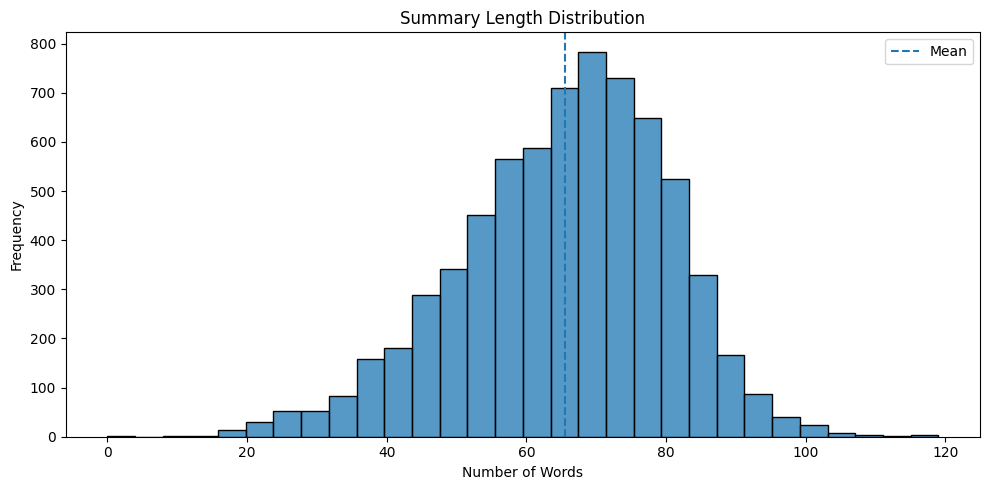

In [48]:
plot_summary_length_distribution(
    summary_length
)

## 7. Text Exploration

In [49]:
from collections import Counter

def get_top_words_from_titles(
    df,
    top_n=20
):
    """
    Extract the most frequent words from news titles.

    Paremeters
    -----------
    df : pandas.DataFrame
        Input dataframe.

    top_n : int, default=20
        Number of top words to return.

    Returns
    -------
    pandas.Series
        Top word frequencies.
    """

    all_words = []

    for title in df["title"].dropna():

        words = str(title).lower().split()

        all_words.extend(words)

    word_counts = Counter(
        all_words
    )

    return pd.Series(
        dict(
            word_counts.most_common(
                top_n
            )
        )
    )

In [50]:
top_words = get_top_words_from_titles(
    economy_df,
    top_n=30
)

top_words

di           1292
ini           922
dan           737
harga         636
rp            518
ri            480
bank          455
ke            429
2023          380
saham         363
jadi          360
ihsg          355
yang          338
dari          317
lebaran       310
impor         300
naik          298
untuk         280
indonesia     277
as            258
juta          247
hingga        235
ada           228
triliun       226
bisa          225
hari          225
tak           221
listrik       198
persen        191
bekas         190
dtype: int64

In [51]:
import re

from collections import Counter
from Sastrawi.StopWordRemover.StopWordRemoverFactory import (
StopWordRemoverFactory
)


def get_clean_top_words_from_titles(
    df,
    top_n=20
):
    """
    Extract the most frequent meaningful words from news titles after removing Indonesian stopwords.

    Parameters
    ----------
    df : pandas.DataFrame
        Input dataframe.

    top_n : int, default=20
        Number of top words to return.

    Returns
    -------
    pandas.Series
        Top cleaned word frequencies.
    """

    factory = StopWordRemoverFactory()

    stopwords = set(
        factory.get_stop_words()
    )

    all_words = []

    for title in df["title"].dropna():

        title = str(title).lower()

        title = re.sub(
            r"[^a-zA-Z\s]",
            " ",
            title
        )

        words = title.split()

        words = [
            word
            for word in words
            if word not in stopwords
            and len(word) > 2
        ]

        all_words.extend(
            words
        )

    word_counts = Counter(
        all_words
    )

    return pd.Series(
        dict(
            word_counts.most_common(
                top_n
            )
        )
    )

In [52]:
clean_top_words = (
    get_clean_top_words_from_titles(
        economy_df,
        top_n=30
    )
)

clean_top_words

harga        644
bank         500
lebaran      401
saham        376
jadi         363
ihsg         358
naik         339
indonesia    328
impor        318
juta         282
triliun      274
persen       243
hari         241
jokowi       240
hingga       235
listrik      226
bekas        223
tak          221
beras        214
turun        205
mudik        196
emas         195
bakal        187
miliar       187
baru         178
pasar        170
ekonomi      167
jelang       162
bisnis       159
per          159
dtype: int64

In [53]:
def plot_top_words(
    word_counts
):
    """
    Visualize the most frequent words.

    Parameters
    ----------
    word_counts : pandas.Series
        Word frequencies
    """

    plt.figure(
        figsize=(12, 6)
    )

    word_counts.sort_values().plot(
        kind="barh"
    )

    plt.title(
        "Most Frequent Words in Economic News Titles"
    )

    plt.xlabel(
        "Frequency"
    )

    plt.ylabel(
        "Words"
    )

    plt.tight_layout()

    plt.show()

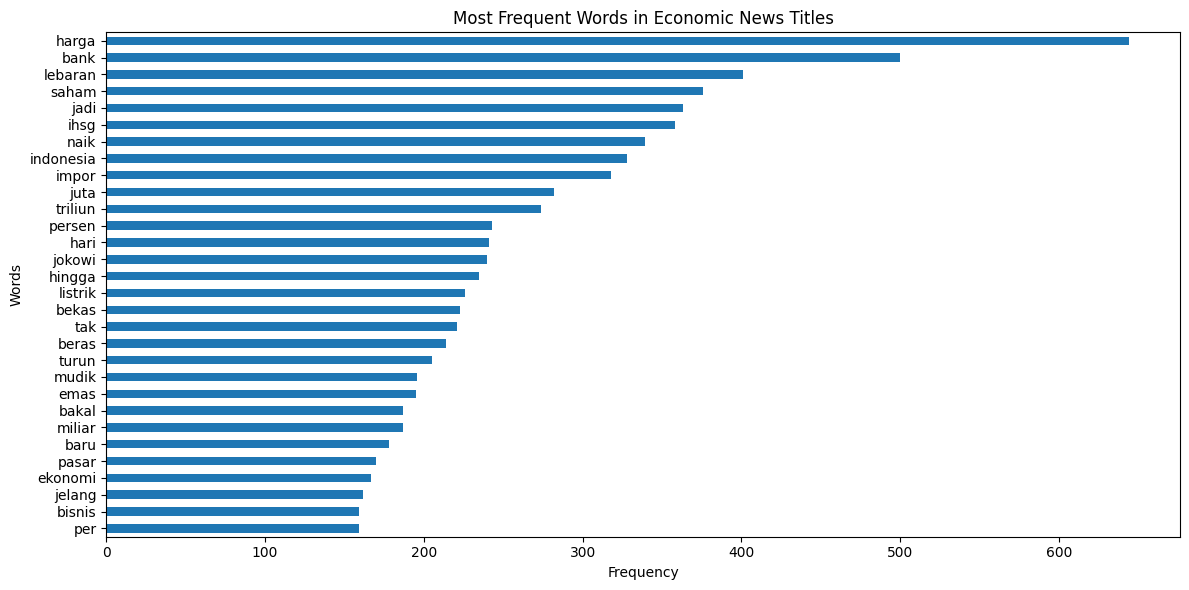

In [54]:
plot_top_words(
    clean_top_words
)

## 8. EDA Summary


Based on the exploratory data analysis, several key findings were identified. First, the economic news dataset contains 6.867 articles published between March and April 2023, providing a relatively large collection of recent economic news. Second, the dataset is dominated by articles from CNBC Indonesia, followed by Okezone and Kumparan, indicating a potential source imbalance to consider during interpretation.

Temporal analysis revealed substantial fluctuations in daily news volume, with noticeable spikes during mid-March 2023. This period coincides with major global financial events, including the Silicon Valley Bank collapse and concerns surrounding Credit Suisse, suggesting that economic news coverage was influenced by significant market developments.

Text analysis showed that article summaries contain approximately 65 words on average, providing sufficient information for downstream natural language processing tasks while remaining computationally efficient compared to full article content.

Finally, the most frequent keywords in news titles include terms such as harga (price), bank, saham (stocks), IHSG, and ekonomi, indicating that the dataset covers topics related to financial markets, banking, macroeconomic conditions, and commodity prices. These findings suggest that the dataset is suitable for sentiment analysis and further investigation of the relationship between economic news sentiment and stock market movements.